<a href="https://colab.research.google.com/github/gcpora/NeuralNexus/blob/main/CarDamageDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import json, os
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
sod_image_dir="/Users/gaurav/Downloads/CarDD_release/CarDD_SOD/CarDD-TR/CarDD-TR-Image"
sod_mask_dir="/Users/gaurav/Downloads/CarDD_release/CarDD_SOD/CarDD-TR/CarDD-TR-Mask"
annotaion_file="/Users/gaurav/Downloads/CarDD_release/CarDD_COCO/annotations/instances_train2017.json"
coco_image_dir="/Users/gaurav/Downloads/CarDD_release/CarDD_COCO/train2017"

Step 1: The Image Preprocessing


1.   Alignment: For every image in sod/image/, find the matching mask in sod/mask/.
2.   Masking: Multiply the image by the mask. This keeps the car and turns everything else (trees, street) into black pixels.
3. Resizing: Force the image into a $224 \times 224$ pixel square.ResNet
4. Normalization: Run the pixels through preprocess_input to shift the color values into the range ResNet50 expects.

In [ ]:
with open(annotaion_file) as f:
  ann=json.load(f)

print("=== COCO ===")
print("Catrgories: ", [c["name"] for c in ann["categories"]])
print("Num images:", len(ann["images"]))
print("Num annotations:", len(ann["annotations"]))
print("Sample annotation:", ann["annotations"][0])

sod_images=list(Path(sod_image_dir).glob("*"))
sod_masks=list(Path(sod_mask_dir).glob("*"))
print("\n=== SOD ===")
print("Catrgories: ", [c["name"] for c in ann["categories"]])
print("Images:", len(sod_images))
print("Masks:", len(sod_masks))
print("Sample image name:", sod_images[0].name)
print("Sample mask name:", sod_masks[0].name)


FileNotFoundError: [Errno 2] No such file or directory: '/Users/gaurav/Downloads/CarDD_release/CarDD_COCO/annotations/instances_train2017.json'

In [2]:
import json
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D


In [40]:
TRAIN_IMG_DIR="/content/sample_data/CarDD/CarDD_COCO/train2017"
TRAIN_ANN_FILE="/content/sample_data/CarDD/CarDD_COCO/annotations/instances_train2017.json"
TEST_IMG_DIR="/content/sample_data/CarDD/CarDD_COCO/test2017"
TEST_ANN_FILE="/content/sample_data/CarDD/CarDD_COCO/annotations/instances_test2017.json"
VAL_IMG_DIR="/content/sample_data/CarDD/CarDD_COCO/val2017"
VAL_ANN_FILE="/content/sample_data/CarDD/CarDD_COCO/annotations/instances_val2017.json"

IMG_SIZE=224
BATCH_SIZE=32

COST_MAP = {
    "dent": 1200,
    "scratch": 500,
    "crack": 800,
    "glass shatter": 2200,
    "lamp broken": 1500,
    "tire flat": 300
}

In [11]:
with open(TRAIN_ANN_FILE) as f:
  ann=json.load(f)

print("Catrgories: ", [c["name"] for c in ann["categories"]])
print("Total Images   :", len(ann["images"]))
print("Total Annotations:", len(ann["annotations"]))

from collections import Counter
cat_lookup = {c["id"]: c["name"] for c in ann["categories"]}
counts = Counter([cat_lookup[a["category_id"]] for a in ann["annotations"]])
print("Annotation per damage type:")
for name, count in counts.most_common():
  print(f"{name:<20}: {count}")

Catrgories:  ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']
Total Images   : 2816
Total Annotations: 6211
Annotation per damage type:
scratch             : 2560
dent                : 1806
crack               : 651
lamp broken         : 494
glass shatter       : 475
tire flat           : 225


In [16]:
def polygon_to_mask(segmentation, img_height, img_weidth):
  mask = np.zeros((img_height, img_weidth), dtype=np.uint8)
  for polygon in segmentation:
    points = np.array(polygon, dtype=np.int32).reshape((-1, 2))
    cv2.fillPoly(mask, [points], color=1)
  return mask

def apply_mask(image, mask):
  mask_3ch=mask[:,:,np.newaxis]
  return image * mask_3ch

In [17]:
def preprocess_image(image, img_size=224):
  resized=cv2.resize(image, (img_size, img_size))
  float_img=resized.astype(np.float32)
  normalized=preprocess_input(float_img)
  return normalized

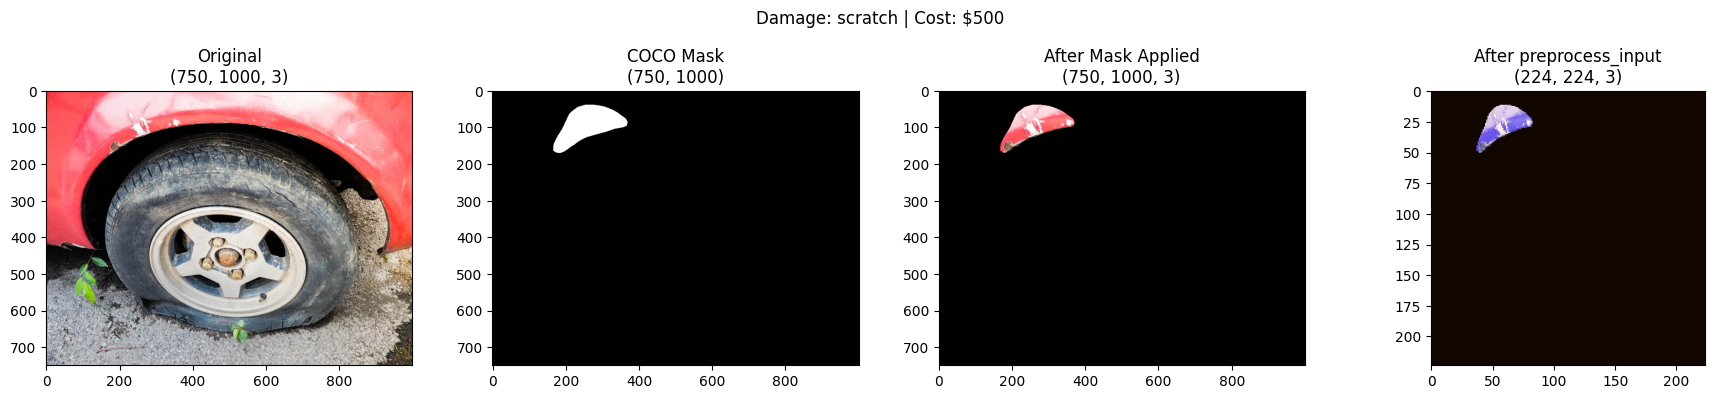

Pixel value smaple after preprocess_input: [-103.939 -116.779 -123.68 ]
Value range: -123.7 to 151.1


In [22]:
sample_ann=ann["annotations"][0]
img_lookup={img["id"]: img["file_name"] for img in ann["images"]}
fname=img_lookup[sample_ann["image_id"]]
img_path=os.path.join(TRAIN_IMG_DIR, fname)
img_bgr=cv2.imread(img_path)
img_rgb=cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w=img_rgb.shape[:2]
mask=polygon_to_mask(sample_ann["segmentation"], h, w)
img_masked=apply_mask(img_rgb, mask)
img_preprocessed=preprocess_image(img_masked)
fig, axes=plt.subplots(1,4,figsize=(18,4))
axes[0].imshow(img_rgb)
axes[0].set_title(f"Original\n{img_rgb.shape}")
axes[1].imshow(mask,cmap="gray")
axes[1].set_title(f"COCO Mask\n{mask.shape}")
axes[2].imshow(img_masked)
axes[2].set_title(f"After Mask Applied\n{img_masked.shape}")
display_img=(img_preprocessed - img_preprocessed.min())
display_img=display_img/display_img.max()
axes[3].imshow(display_img)
axes[3].set_title(f"After preprocess_input\n{img_preprocessed.shape}")
damage_type=cat_lookup[sample_ann["category_id"]]
plt.suptitle(f"Damage: {damage_type} | Cost: ${COST_MAP[damage_type]}")
plt.tight_layout()
plt.show()
print(f"Pixel value smaple after preprocess_input: {img_preprocessed[100, 100]}")
print(f"Value range: {img_preprocessed.min():.1f} to {img_preprocessed.max():.1f}")

In [23]:
def build_feature_extractor():
  base_model=ResNet50(
      weights="imagenet",
      include_top=False,
      input_shape=(IMG_SIZE, IMG_SIZE, 3)
  )
  x=base_model.output
  output=GlobalAveragePooling2D()(x)
  model=Model(inputs=base_model.input, outputs=output)
  model.trainable=False
  print(f"Input shape: {model.input_shape}")
  print(f"Output shape: {model.output_shape}")
  return model
feature_extractor=build_feature_extractor()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Input shape: (None, 224, 224, 3)
Output shape: (None, 2048)


In [26]:
def build_dataset(ann_file, img_dir, cost_map, img_size=IMG_SIZE):
  with open(ann_file) as f:
    coco_data=json.load(f)
  cat_lookup={c["id"]: c["name"] for c in coco_data["categories"]}
  img_lookup={img["id"]: img["file_name"] for img in coco_data["images"]}
  images=[]
  costs=[]
  meta=[]
  skipped=0

  for i, ann in enumerate(coco_data["annotations"]):
    cat_name=cat_lookup[ann["category_id"]]
    if cat_name not in cost_map:
      skipped+=1
      continue

    fname=img_lookup[ann["image_id"]]
    img_path=os.path.join(img_dir, fname)

    if not os.path.exists(img_path):
      skipped+=1
      continue

    img_bgr=cv2.imread(img_path)
    img_rgb=cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w=img_rgb.shape[:2]
    mask=polygon_to_mask(ann["segmentation"], h, w)
    img_masked=apply_mask(img_rgb, mask)
    img_preprocessed=preprocess_image(img_masked, img_size)

    images.append(img_preprocessed)
    costs.append(float(cost_map[cat_name]))
    meta.append({"file": fname, "damage": cat_name})

    if (i+1) % 500 == 0:
      print(f"  {i+1}/{len(coco_data['annotations'])} annotations processes..")
  print(f"Done - built: {len(images)} samples | skipped: {skipped}")
  return images, costs, meta

In [39]:
print("Building TRAIN set...")
train_images, train_costs, train_meta = build_dataset(TRAIN_ANN_FILE, TRAIN_IMG_DIR, COST_MAP)

Building TRAIN set...
  500/6211 annotations processes..
  1000/6211 annotations processes..
  1500/6211 annotations processes..
  2000/6211 annotations processes..
  2500/6211 annotations processes..
  3000/6211 annotations processes..
  3500/6211 annotations processes..
  4000/6211 annotations processes..
  4500/6211 annotations processes..
  5000/6211 annotations processes..
  5500/6211 annotations processes..
  6000/6211 annotations processes..
Done - built: 6211 samples | skipped: 0

Building VAL set...


NameError: name 'VAL_ANN_FILE' is not defined

In [41]:
print("\nBuilding VAL set...")
val_images, val_costs, val_meta = build_dataset(VAL_ANN_FILE, VAL_IMG_DIR, COST_MAP)

print("\nBuilding TEST set...")
test_images, test_costs, test_meta = build_dataset(TEST_ANN_FILE, TEST_IMG_DIR, COST_MAP)

print(f"\nSplit sizes:")
print(f"  TRAIN: {len(train_images)}")
print(f"  VAL: {len(val_images)}")
print(f"  TEST: {len(test_images)}")


Building VAL set...
  500/1744 annotations processes..
  1000/1744 annotations processes..
  1500/1744 annotations processes..
Done - built: 1744 samples | skipped: 0

Building TEST set...
  500/785 annotations processes..
Done - built: 785 samples | skipped: 0

Split sizes:
  TRAIN: 6211
  VAL: 1744
  TEST: 785


In [43]:
def extract_features(images, model, batch_size=BATCH_SIZE):
  all_features=[]
  total=len(images)
  #total=320
  for start in range(0, total, batch_size):
    end=min(start+batch_size, total)
    batch=np.array(images[start:end])
    feats=model.predict(batch, verbose=0)
    all_features.append(feats)
    if (start // batch_size+1) %10 == 0:
      print(f"  {end}/{total} images done...")
  X=np.vstack(all_features)
  print(f"Feature matrix shape: {X.shape}")
  return X
print("Extracting TRAIN features...")
X_train=extract_features(train_images, feature_extractor)
y_train=np.array(train_costs)

print("\nExtracting VAL features...")
X_val=extract_features(val_images, feature_extractor)
y_val=np.array(val_costs)

print("\nExtracting TEST features...")
X_test=extract_features(test_images, feature_extractor)
y_test=np.array(test_costs)

print(f"\nShapes:")
print(f"  X_train: {X_train.shape} y_train: {y_train.shape}")
print(f"  X_val: {X_val.shape} y_val: {y_val.shape}")
print(f"  X_test: {X_test.shape} y_test: {y_test.shape}")


Extracting TRAIN features...
  320/6211 images done...
  640/6211 images done...
  960/6211 images done...
  1280/6211 images done...
  1600/6211 images done...
  1920/6211 images done...
  2240/6211 images done...
  2560/6211 images done...
  2880/6211 images done...
  3200/6211 images done...
  3520/6211 images done...
  3840/6211 images done...
  4160/6211 images done...
  4480/6211 images done...
  4800/6211 images done...
  5120/6211 images done...
  5440/6211 images done...
  5760/6211 images done...
  6080/6211 images done...
Feature matrix shape: (6211, 2048)

Extracting VAL features...
  320/1744 images done...
  640/1744 images done...
  960/1744 images done...
  1280/1744 images done...
  1600/1744 images done...
Feature matrix shape: (1744, 2048)

Extracting TEST features...
  320/785 images done...
  640/785 images done...
Feature matrix shape: (785, 2048)

Shapes:
  X_train: (6211, 2048) y_train: (6211,)
  X_val: (1744, 2048) y_val: (1744,)
  X_test: (785, 2048) y_test: (

In [36]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
print(f"X_train mean (should be ~0): {X_train.mean():.4f}")
print(f"X_train std (should be ~1): {X_train.std():.4f}")
#

X_train mean (should be ~0): -0.0000
X_train std (should be ~1): 1.0000


In [42]:
model=xgb.XGBRegressor(
    n_estimaors=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    tree_methos="hist",
    early_stopping_rounds=20,
    eval_metric="mae",
    random_state=42
)

model.fit(
    X_train, y_train,
    verbose=50,
    eval_set=[(X_val, y_val)]
)

print(f"Best iteration: {model.best_iteration}")

NameError: name 'X_val' is not defined